In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge

from sklearn.feature_selection import RFE

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score 
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Databse
dataset = pd.read_csv("PA6_update_dataset_PHRR.csv")
#dataset = pd.read_csv("LOI_Database.csv")
#dataset = pd.read_csv("pHRR_Database.csv")
#dataset = pd.read_csv("THR_Database.csv")
#dataset = pd.read_csv("94_Database.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values


dataset_BDOPO_OH = pd.read_csv("3montakhab_PA6.csv")
X_BDOPO_OH = dataset_BDOPO_OH


# train test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)
# LOI, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=80)
# PHRR, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=82)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.02, random_state=5)
# 94, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=76)

# Data processing
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_BDOPO_OH = scaler.transform(X_BDOPO_OH)

# Feature Selection
#estimator = Ridge(alpha=45, random_state=1, max_iter=100000)
# LOI, estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
#estimator = Ridge(alpha=20, random_state=1, max_iter=100000)
# 94, estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
#selector = RFE(estimator, n_features_to_select = 153)
selector = RFE(estimator, n_features_to_select =102)
# PHRR, selector = RFE(estimator, n_features_to_select = 203)
#selector = RFE(estimator, n_features_to_select = 23)
# 94, selector = RFE(estimator, n_features_to_select = 13)
selector.fit(X_train, y_train)
X_train_selector = selector.transform(X_train)
X_test_selector =selector.transform(X_test) 
X_BDOPO_OH_selector = selector.transform(X_BDOPO_OH)
                 
# Output Selected Feature
feature_selected = selector.get_support()
logf = open("logfile.log", "a+")
np.set_printoptions(threshold=np.inf)
print(f"{feature_selected}", file=logf, flush=True)

# Regression
#regressor = GradientBoostingRegressor(n_estimators=210, max_depth=4, random_state=1)
regressor = GradientBoostingRegressor(n_estimators=120, max_depth=3, random_state=42)
# PHRR, regressor = GradientBoostingRegressor(n_estimators=410, max_depth=3, random_state=1)
#regressor = GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=1)
# 94, regressor = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=1)
 
regressor.fit(X_train_selector, y_train)

# Output feature importance
feature_importances_ = regressor.feature_importances_

# Model Performance
# LOI, PHRR, THR, TII
y_train_predict = regressor.predict(X_train_selector)
y_predict = regressor.predict(X_test_selector)
mean_squared_error = mean_squared_error(y_test, y_predict)
root_mean_squard_error = mean_squared_error**0.5
mean_absolute_error = mean_absolute_error(y_test, y_predict)
# 94
#accuracy_score_train = accuracy_score(y_train, y_train_predict)
#accuracy_score_test = accuracy_score(y_test, y_predict)
#precision_score = precision_score(y_test, y_predict, average='weighted')
#recall_score = recall_score(y_test, y_predict, average='weighted')
#f1_score = f1_score(y_test, y_predict, average='weighted')
                                                                        
print(f"train R2: {regressor.score(X_train_selector, y_train):.3f}")
print(f"test R2: {regressor.score(X_test_selector, y_test):.3f}")

# Predict EP/BDOPO
y_BDOPO_OH_predict = regressor.predict(X_BDOPO_OH_selector)

C:\Users\u1148893\AppData\Local\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


train R2: 0.983
test R2: 0.857


In [2]:
y_BDOPO_OH_predict

array([ -9.04146746, -11.44796799, -14.34147352, -12.4385893 ,
       -11.3252466 , -15.40388801, -15.97102691, -19.14293781,
       -18.58904248, -18.58904248,   0.53992919,  -1.86657135,
        -2.83575898,  -0.93287475,   0.18046795,  -3.89817347,
        -4.46531236,  -7.63722326,  -7.08332794,  -7.08332794,
         2.60080032,   0.19429979,  -2.05351236,  -0.15062813,
         0.96271457,  -2.27240147,  -2.27240147,  -4.07556434,
        -5.42327138,  -5.42327138])

In [14]:
# -*- coding: utf-8 -*-
"""
@author: Zhongwei Chen
Email: czw1995@outlook.com
"""
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge

from sklearn.feature_selection import RFE

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score 
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Databse
dataset = pd.read_csv("PA6_PHRR.csv")
#dataset = pd.read_csv("LOI_Database.csv")
#dataset = pd.read_csv("pHRR_Database.csv")
#dataset = pd.read_csv("THR_Database.csv")
#dataset = pd.read_csv("94_Database.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values


dataset_BDOPO_OH = pd.read_csv("3montakhab_PA6.csv")
X_BDOPO_OH = dataset_BDOPO_OH


# train test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)
# LOI, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=80)
# PHRR, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=82)
#PHRRX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=10)

# 94, X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=76)

# Data processing
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_BDOPO_OH = scaler.transform(X_BDOPO_OH)

# Feature Selection
#estimator = Ridge(alpha=45, random_state=1, max_iter=100000)
# LOI, estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
#estimator = Ridge(alpha=20, random_state=1, max_iter=100000)
# 94, estimator = Ridge(alpha=1, random_state=1, max_iter=100000)
#selector = RFE(estimator, n_features_to_select = 153)
selector = RFE(estimator, n_features_to_select =82)
# PHRR, selector = RFE(estimator, n_features_to_select = 203)
#selector = RFE(estimator, n_features_to_select = 23)
# 94, selector = RFE(estimator, n_features_to_select = 13)
selector.fit(X_train, y_train)
X_train_selector = selector.transform(X_train)
X_test_selector =selector.transform(X_test) 
X_BDOPO_OH_selector = selector.transform(X_BDOPO_OH)
                 
# Output Selected Feature
feature_selected = selector.get_support()
logf = open("logfile.log", "a+")
np.set_printoptions(threshold=np.inf)
print(f"{feature_selected}", file=logf, flush=True)

# Regression
#regressor = GradientBoostingRegressor(n_estimators=210, max_depth=4, random_state=1)
regressor = GradientBoostingRegressor(n_estimators=120, max_depth=2, random_state=42)
# PHRR, regressor = GradientBoostingRegressor(n_estimators=410, max_depth=3, random_state=1)
#regressor = GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=1)
# 94, regressor = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=1)
 
regressor.fit(X_train_selector, y_train)

# Output feature importance
feature_importances_ = regressor.feature_importances_

# Model Performance
# LOI, PHRR, THR, TII
y_train_predict = regressor.predict(X_train_selector)
y_predict = regressor.predict(X_test_selector)
mean_squared_error = mean_squared_error(y_test, y_predict)
root_mean_squard_error = mean_squared_error**0.5
mean_absolute_error = mean_absolute_error(y_test, y_predict)
# 94
#accuracy_score_train = accuracy_score(y_train, y_train_predict)
#accuracy_score_test = accuracy_score(y_test, y_predict)
#precision_score = precision_score(y_test, y_predict, average='weighted')
#recall_score = recall_score(y_test, y_predict, average='weighted')
#f1_score = f1_score(y_test, y_predict, average='weighted')
                                                                        
print(f"train R2: {regressor.score(X_train_selector, y_train):.3f}")
print(f"test R2: {regressor.score(X_test_selector, y_test):.3f}")

# Predict EP/BDOPO
y_BDOPO_OH_predict = regressor.predict(X_BDOPO_OH_selector)

C:\Users\u1148893\AppData\Local\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


train R2: 0.972
test R2: 0.723


In [15]:
y_BDOPO_OH_predict

array([ 891.4690433 ,  840.62239202,  809.62563214,  806.80051537,
        812.45704643,  760.76993826,  760.76993826,  760.76993826,
        760.76993826,  741.12910363,  910.27621991,  859.42956863,
        828.43280875,  825.60769198,  831.26422304,  766.00740379,
        766.00740379,  766.00740379,  766.00740379,  746.36656916,
       1026.99712998,  976.1504787 ,  945.15371882,  942.32860205,
        947.9851331 ,  882.72831386,  882.72831386,  882.72831386,
        882.72831386,  863.08747922])

In [16]:
mean_squared_error

10441.958390034984

In [17]:
root_mean_squard_error

102.18590113139378

In [10]:
mean_absolute_error

73.35379766132236

In [43]:
import pandas as pd

# Create a DataFrame with actual and predicted values
df_train_results = pd.DataFrame({
    "Actual Values": y_train,
    "Predicted Values": y_train_predict
})

# Save to Excel
df_train_results.to_excel("train_predictions_PA6_PHRR.csv.xlsx", index=False)

print("Training predictions saved to train_predictions_PA6_PHRR.csv.xlsx")

Training predictions saved to train_predictions_PA6_PHRR.csv.xlsx


In [44]:
import pandas as pd

# Create a DataFrame with actual and predicted values
df_train_results = pd.DataFrame({
    "Actual Values": y_test,
    "Predicted Values": y_predict
})

# Save to Excel
df_train_results.to_excel("test_predictions_PA6_PHRR.csv.xlsx", index=False)

print("Training predictions saved to test_predictions_PA6_PHRR.csv.xlsx")

Training predictions saved to test_predictions_PA6_PHRR.csv.xlsx


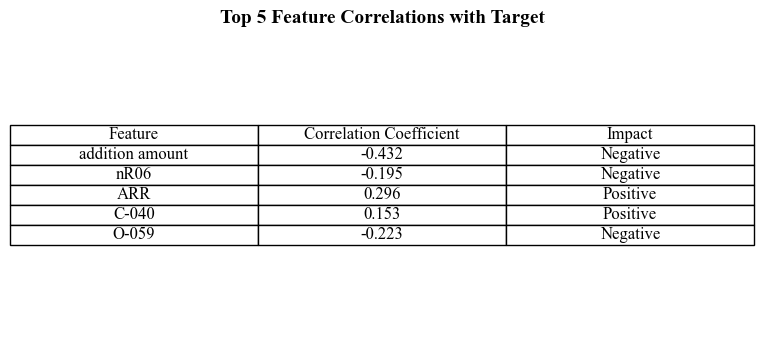

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Set font to Times New Roman
matplotlib.rcParams["font.family"] = "Times New Roman"

# Load dataset
dataset = pd.read_csv("PA6_PHRR.csv")

# Extract features and target variable
X = dataset.iloc[:, :-1]  # Features
y = dataset.iloc[:, -1]   # Target variable

# Compute feature importance from the model
feature_importances = regressor.feature_importances_

# Map selected features back to original dataset column names
selected_feature_names = dataset.columns[:-1][selector.get_support()]

# Sort features by importance in descending order
sorted_indices = np.argsort(feature_importances)[::-1]
top_5_features = [selected_feature_names[i] for i in sorted_indices[:5]]

# Compute correlation for only the top 5 features
correlation_matrix = X[top_5_features].corrwith(y)

# Create a table plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("tight")
ax.axis("off")
table_data = [["Feature", "Correlation Coefficient", "Impact"]]
for feature, corr_value in correlation_matrix.items():
    impact = "Positive" if corr_value > 0 else "Negative"
    table_data.append([feature, f"{corr_value:.3f}", impact])

# Create table in the plot
table = ax.table(cellText=table_data, colLabels=None, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

# Show table
plt.title("Top 5 Feature Correlations with Target", fontsize=14, fontweight="bold")
plt.show()